# EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
fake = pd.read_csv("/content/Fake.csv", engine='python', on_bad_lines='skip')
real = pd.read_csv("/content/True.csv", engine='python', on_bad_lines='skip')

In [11]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [12]:
real.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [13]:
fake["label"] = 0
real["label"] = 1

In [14]:
df = pd.concat([fake, real], ignore_index=True)

In [15]:
print("Dataset shape:", df.shape)

Dataset shape: (13067, 5)


In [16]:
print(df.columns)

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13067 entries, 0 to 13066
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    13067 non-null  object
 1   text     13067 non-null  object
 2   subject  13067 non-null  object
 3   date     13067 non-null  object
 4   label    13067 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 510.6+ KB


In [18]:
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [19]:
df["label"].value_counts()

,count
label,
0,6953
1,6114


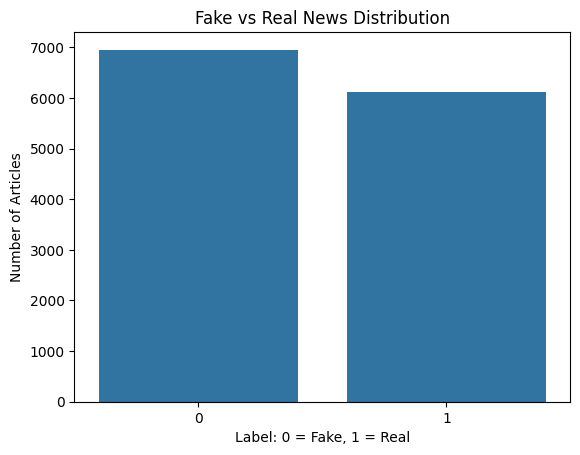

In [20]:
sns.countplot(x=df["label"])
plt.title("Fake vs Real News Distribution")
plt.xlabel("Label: 0 = Fake, 1 = Real")
plt.ylabel("Number of Articles")
plt.show()

In [21]:
df["full_text"] = df["title"] + " " + df["text"]

In [22]:
df["text_length"] = df["full_text"].apply(len)

In [23]:
df["text_length"].describe()

,text_length
count,13067.000000
mean,2601.146399
std,1361.311056
min,219.000000
25%,1928.000000
50%,2463.000000
75%,3192.000000
max,29849.000000


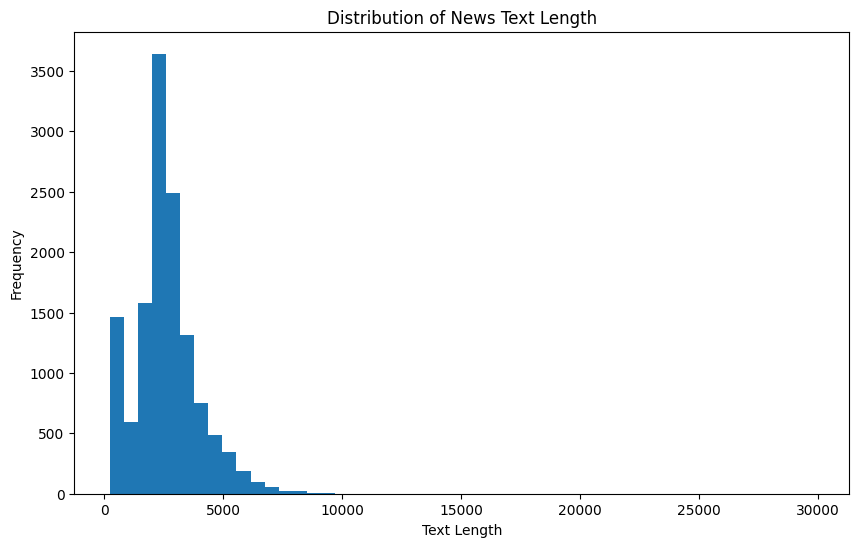

In [24]:
plt.figure(figsize=(10, 6))
plt.hist(df["text_length"], bins=50)
plt.title("Distribution of News Text Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

In [25]:
df.groupby("label")["text_length"].mean()

,text_length
label,
0,2685.380268
1,2505.353451


In [26]:
fake_example = df[df["label"] == 0].iloc[0]

print("TITLE:")
print(fake_example["title"])

print("\nTEXT:")
print(fake_example["text"][:1000])

TITLE:
 Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing

TEXT:
Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year,  President Angry Pants tweeted.  2018 will be a great year for America! As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year. 2018 will be a great year for America!  Donald J. Trump (@realDonaldTrump) December 31, 2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Year s greeti

In [27]:
real_example = df[df["label"] == 1].iloc[0]

print("TITLE:")
print(real_example["title"])

print("\nTEXT:")
print(real_example["text"][:1000])

TITLE:
As U.S. budget fight looms, Republicans flip their fiscal script

TEXT:
WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fiscal conservative” on Sunday and urged budget restraint in 2018. In keeping with a sharp pivot under way among Republicans, U.S. Representative Mark Meadows, speaking on CBS’ “Face the Nation,” drew a hard line on federal spending, which lawmakers are bracing to do battle over in January. When they return from the holidays on Wednesday, lawmakers will begin trying to pass a federal budget in a fight likely to be linked to other issues, such as immigration policy, even as the November congressional election campaigns approach in which Republicans will seek to keep control of Congress. President Donald Trump and his Republicans want a big budget increase in military spending, while Democrats also want proportional incr

In [28]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [29]:
df.head()

,title,text,subject,date,label,full_text,text_length
0,WATCH: Joy Reid Shuts Down Trump Supporter Fo...,"Once again, a mouthpiece for Donald Trump gets...",News,"September 10, 2016",0,WATCH: Joy Reid Shuts Down Trump Supporter Fo...,3188
1,IRS Slams Trump Foundation For Breaking The Law,The Donald J. Trump Foundation just quietly pa...,News,"September 1, 2016",0,IRS Slams Trump Foundation For Breaking The L...,2041
2,Trump vows to protect 'Made in America' products,WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,"July 17, 2017",1,Trump vows to protect 'Made in America' produc...,2619
3,"Thanks To Trump, Companies Are Pulling Out Of...",Now that Republicans are only a month away fro...,News,"June 17, 2016",0,"Thanks To Trump, Companies Are Pulling Out Of...",2344
4,Here’s Trump’s Hilariously Illegal Plan To Fo...,Donald Trump has long insisted that he is goin...,News,"July 20, 2016",0,Here’s Trump’s Hilariously Illegal Plan To Fo...,2638


The dataset contains approximately 40,000 news articles with balanced fake and real classes. News articles vary significantly in text length. The dataset appears suitable for text classification using deep learning models such as RNN, LSTM, and GRU.

#   BASELINE MODEL (TF-IDF + LOGISTIC REGRESSION)

In [31]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

TRAIN / VALIDATION / TEST SPLIT

In [35]:
X = df["full_text"]
y = df["label"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

Train size: 9146
Validation size: 1960
Test size: 1961


TF-IDF VECTORIZATION

In [36]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english"
)

In [37]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

LOGISTIC REGRESSION MODEL

In [38]:
baseline_model = LogisticRegression(max_iter=1000)

In [39]:
baseline_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [41]:
val_predictions = baseline_model.predict(X_val_tfidf)

val_accuracy = accuracy_score(y_val, val_predictions)
val_precision = precision_score(y_val, val_predictions)
val_recall = recall_score(y_val, val_predictions)
val_f1 = f1_score(y_val, val_predictions)
print("Validation Accuracy:", val_accuracy)
print("Validation Precision:", val_precision)
print("Validation Recall:", val_recall)
print("Validation F1-score:", val_f1)

Validation Accuracy: 0.9908163265306122
Validation Precision: 0.990185387131952
Validation Recall: 0.990185387131952
Validation F1-score: 0.990185387131952


In [42]:
print(classification_report(y_val, val_predictions))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1043
           1       0.99      0.99      0.99       917

    accuracy                           0.99      1960
   macro avg       0.99      0.99      0.99      1960
weighted avg       0.99      0.99      0.99      1960



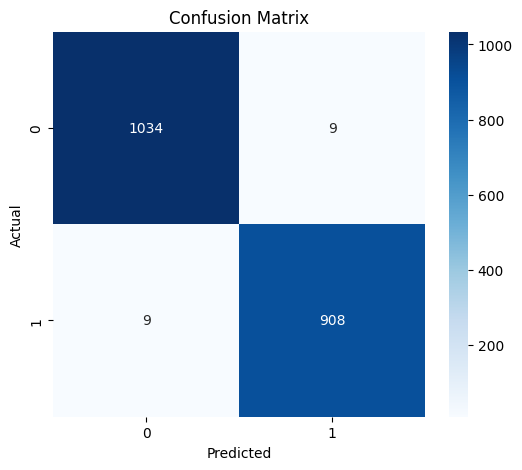

In [44]:
cm = confusion_matrix(y_val, val_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [46]:
test_predictions = baseline_model.predict(X_test_tfidf)
test_accuracy = accuracy_score(y_test, test_predictions)
test_precision = precision_score(y_test, test_predictions)
test_recall = recall_score(y_test, test_predictions)
test_f1 = f1_score(y_test, test_predictions)
print("TEST RESULTS")
print("Accuracy:", test_accuracy)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1-score:", test_f1)

TEST RESULTS
Accuracy: 0.9898011218765935
Precision: 0.990174672489083
Recall: 0.9880174291938998
F1-score: 0.9890948745910578


In [47]:
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1
    ]
})

results

,Metric,Score
0,Accuracy,0.989801
1,Precision,0.990175
2,Recall,0.988017
3,F1-score,0.989095


In [50]:
sample_texts = X_test.iloc[:5]

sample_predictions = baseline_model.predict(
    vectorizer.transform(sample_texts)
)
for i in range(5):

    print("TEXT:")
    print(sample_texts.iloc[i][:500])

    print("\nPREDICTION:", sample_predictions[i])

    print("REAL LABEL:", y_test.iloc[i])

    print("\n" + "="*80 + "\n")

TEXT:
Republican senator criticizes Trump tax plan WASHINGTON (Reuters) - U.S. Senator Rand Paul, a conservative maverick who helped kill the latest Republican effort to overturn Obamacare, took issue with President Donald Trump’s tax plan on Monday, asking in a tweet if it was really Republican. “This is a GOP tax plan? Possibly 30 percent of middle class gets a tax hike? I hope the final details are better than this,” the Kentucky Republican said in a statement on Twitter. He cited the results of a 

PREDICTION: 1
REAL LABEL: 1


TEXT:
Trump health nominee says he does not back Medicare privatization (Reuters) - President Donald Trump’s nominee to run the U.S. Department of Health and Human Services told a congressional panel on Tuesday that he does not support the privatization of Medicare and defended his ethics record. Speaking before the Senate Committee on Finance, one of two committees that oversee the health department, Representative Tom Price said his position was consistent

text preprocessing and train/validation/test splitting were completed.

TF-IDF vectorization was applied to convert text into numerical feature vectors.

A Logistic Regression baseline model was implemented and trained on the dataset.


The baseline model achieved strong performance on the fake news classification task.

The TF-IDF representation captured important textual patterns and allowed the Logistic Regression model to separate fake and real news effectively.


# DEEP LEARNING MODELS (RNN / LSTM / GRU)

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from collections import Counter
import re

In [94]:
X = df["full_text"]
y = df["label"]

In [95]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

def tokenize(text):

    text = text.lower()

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    tokens = text.split()

    return tokens

BUILD VOCABULARY

In [96]:
counter = Counter()

for text in X_train:

    counter.update(tokenize(text))

In [97]:
from collections import Counter

counter = Counter()

for text in X_train:
    counter.update(tokenize(text))

vocab = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, count in counter.items():

    if count >= 2:

        vocab[word] = len(vocab)

print("Vocabulary size:", len(vocab))

Vocabulary size: 37296


In [98]:
MAX_LEN = 300

def encode(text):

    tokens = tokenize(text)

    ids = []

    for token in tokens[:MAX_LEN]:

        ids.append(vocab.get(token, vocab["<UNK>"]))

    if len(ids) < MAX_LEN:

        ids += [vocab["<PAD>"]] * (MAX_LEN - len(ids))

    return ids

X_train_encoded = [encode(text) for text in X_train]

X_val_encoded = [encode(text) for text in X_val]

X_test_encoded = [encode(text) for text in X_test]

In [99]:
X_train_tensor = torch.tensor(X_train_encoded, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_encoded, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_encoded, dtype=torch.long)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)

y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

print(X_train_tensor.shape)

print(y_train_tensor.shape)

torch.Size([9146, 300])
torch.Size([9146])


In [100]:
class NewsDataset(Dataset):

    def __init__(self, X, y):

        self.X = X

        self.y = y

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

train_dataset = NewsDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = NewsDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = NewsDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32
)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


In [101]:
class LSTMModel(nn.Module):

    def __init__(self, vocab_size):

        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=64,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=128,
            batch_first=True
        )

        self.fc = nn.Linear(128, 1)

    def forward(self, x):

        x = self.embedding(x)

        output, (hidden, cell) = self.lstm(x)

        hidden = hidden[-1]

        out = self.fc(hidden)

        return out.squeeze(1)

In [103]:
vocab_size = len(vocab)

model = LSTMModel(vocab_size).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [104]:
train_losses = []

val_losses = []

EPOCHS = 5

for epoch in range(EPOCHS):

    model.train()

    total_train_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)

        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    train_losses.append(avg_train_loss)

    model.eval()

    total_val_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)

            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)

    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}")

    print(f"Train Loss: {avg_train_loss:.4f}")

    print(f"Validation Loss: {avg_val_loss:.4f}")

Epoch 1
Train Loss: 0.3980
Validation Loss: 0.5536
Epoch 2
Train Loss: 0.2655
Validation Loss: 0.3102
Epoch 3
Train Loss: 0.1705
Validation Loss: 0.0901
Epoch 4
Train Loss: 0.1114
Validation Loss: 0.0548
Epoch 5
Train Loss: 0.0476
Validation Loss: 0.0464


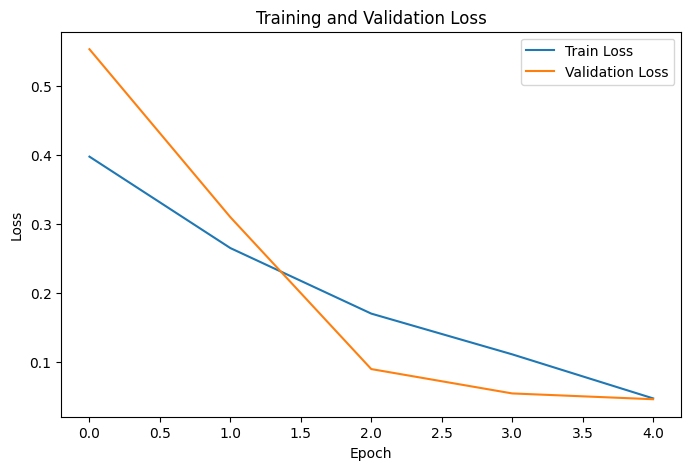

In [105]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [106]:
model.eval()
predictions = []
true_labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).int()
        predictions.extend(preds.cpu().numpy())
        true_labels.extend(y_batch.numpy())

In [108]:
accuracy = accuracy_score(
    true_labels,
    predictions
)
precision = precision_score(
    true_labels,
    predictions
)
recall = recall_score(
    true_labels,
    predictions
)

f1 = f1_score(
    true_labels,
    predictions
)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.9882712901580826
Precision: 0.982740021574973
Recall: 0.9923747276688453
F1-score: 0.9875338753387534


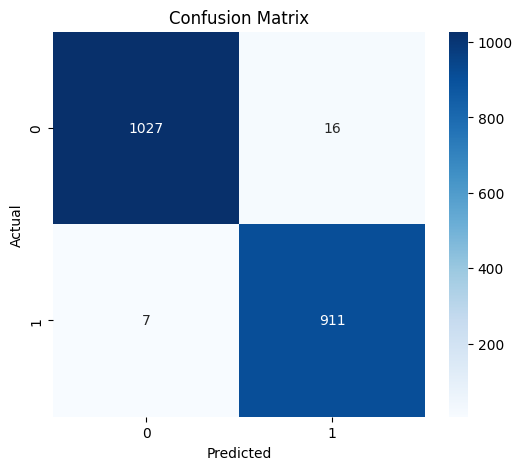

In [110]:
cm = confusion_matrix(
    true_labels,
    predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()